# Introduction

Consider a 2D square lattice with competing (anti)ferromagnetic interactions described by the Hamiltonian
$$
\mathcal{H} = 
-J_1 \sum_{\langle i j \rangle} S_i \cdot S_j 
-J_2 \sum_{\langle\langle i j \rangle\rangle} S_i \cdot S_j 
-J_3 \sum_{\langle\langle\langle i j \rangle\rangle\rangle} S_i \cdot S_j 
- \sum_{i} B_i \cdot S_i - K \sum_i (S_i^{(z)})^2
$$
where $J_1, J_2, J_3$ describe nearest, next-nearest, and next-next nearest neighbour coupling and $K$ is an easy-axis anisotropy. In the continuum approximation, the Hamiltonian is
$$
\mathcal{H} = \int dr \Big( -\frac{I_1}{2} (\nabla S)^2 + \frac{I_2}{2} (\nabla^2 S)^2 - H\cdot S - K' (S^{(z)})^2  \Big)
$$
where 
$$
I_1 = -2\cdot (J_1+J_2+4J_3)\\
I_2 = -\frac{1}{8} a^2 (J_1 + 4 J_2 + 16 J_3)\\
H = \frac{1}{a^2} B\\
K' = \frac{1}{a^2} K
$$

If $I_1<0$ (e.g. when there are only ferromagnetic couplings), the first term favourizes spin alignment and ignoring $I_4$, we obtain the standard nonlinear $\sigma$ model. The interesting behavior occurs for $I_1>0$ where the first term favours high spatial gradients and we need the competing term to regularize the continuum theory.

Introducing the length scale $x_0 = \sqrt{I_2/I_1}$, we can write the Hamiltonian as
$$
\mathcal{H} = \int dr \Big( -\frac{1}{2} (\nabla S)^2 + \frac{1}{2} (\nabla^2 S)^2 - H'\cdot S - K'' (S^{(z)})^2  \Big)
$$
and the new, non-dimensionalized constants (with ') are
$$
H' = \frac{I_2}{I_1^2} H \qquad K'' = \frac{I_2}{I_1^2} K'
$$

## The skyrmion

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
def describe_mean_field(J1,J2,J3):
    I1 = -2*(J1+J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    print("I1 = ", I1,"\nI2 = ", I2)
    print("spatial anisotropy ratio : ", I3/I2)
    x0 = np.sqrt(I2/I1)
    print("sqrt(I2/I1) length scale = ", x0)
    print("H_MF = ",I2/I1**2, " H_Micro")
    return x0

J1 = 1.0; J2 = -0.5; J3 = 1/16*(-J1+4*J2); K = 0.0
describe_mean_field(J1,J2,J3)

I1 =  0.5 
I2 =  0.5
spatial anisotropy ratio :  0.0
sqrt(I2/I1) length scale =  1.0
H_MF =  2.0  H_Micro


np.float64(1.0)

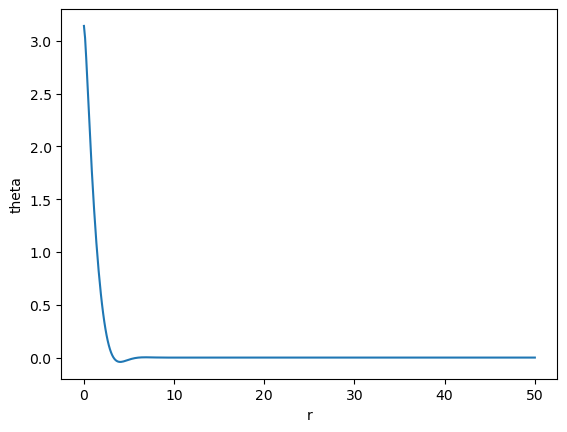

In [53]:
from scipy.integrate import solve_bvp

def theta_profile(H_non_dim):
    L = 50.0
    def ode(r, y):
        theta = y[0]
        dtheta = y[1]
        ddtheta = y[2]
        dddtheta = y[3]

        A = -np.sin(2*theta)

        B = r*(1 + 2*np.cos(2*theta))*dtheta

        C = r**2*((dtheta**2 - 0.5)*np.sin(2*theta)
                -(1 + 2*np.cos(2*theta))*ddtheta)

        D = r**3*(dtheta - 2*dtheta**3 + 2*dddtheta)

        E = r**4*(H_non_dim*np.sin(theta) + ddtheta - 6*dtheta**2*ddtheta)

        theta4 = -(A + B + C + D + E)/r**4

        return np.vstack((dtheta,
                        ddtheta,
                        dddtheta,
                        theta4))


    def bc(ya, yb):
        return np.array([
            ya[0] - np.pi,   # theta(0)
            ya[1],           # theta'(0)
            yb[0],           # theta(L)
            yb[1]            # theta'(L)
        ])


    # mesh
    r = np.linspace(1e-4, L, 400)

    # initial guess
    y_guess = np.zeros((4, r.size))
    y_guess[0] = np.pi*np.exp(-r)

    sol = solve_bvp(ode, bc, r, y_guess, max_nodes=10000)

    r_plot = np.linspace(1e-4, L, 400)
    theta = sol.sol(r_plot)[0]

    plt.plot(r_plot, theta)
    plt.xlabel("r")
    plt.ylabel("theta")
    plt.show()
    return r_plot, theta
#end

r_non_dim, theta = theta_profile(H_non_dim = 4.3)

I1 =  0.5 
I2 =  0.5
spatial anisotropy ratio :  0.0
sqrt(I2/I1) length scale =  1.0
H_MF =  2.0 * H_Micro =  0.4


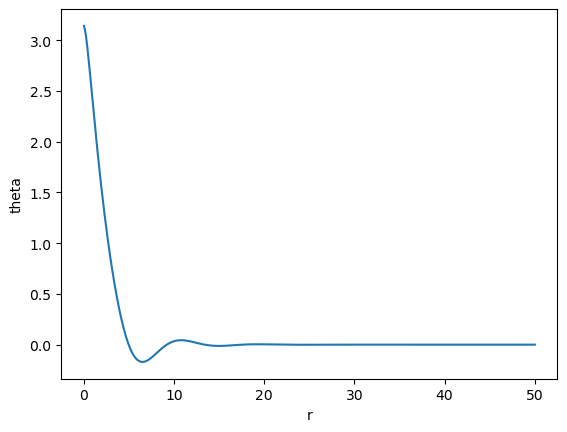

In [54]:
def mean_field_skyrmion(nx,ny,J1,J2,J3,B):
    I1 = -2*(J1+J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    print("I1 = ", I1,"\nI2 = ", I2)
    print("spatial anisotropy ratio : ", I3/I2)
    x0 = np.sqrt(I2/I1)
    H_non_dim = I2/I1**2 * B
    print("sqrt(I2/I1) length scale = ", x0)
    print("H_MF = ",I2/I1**2, "* H_Micro = ", H_non_dim)
    r, theta = theta_profile(H_non_dim)

    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    
    R = np.sqrt(X**2+Y**2)
    r_non_dim = R/x0
    Theta = np.zeros_like(R)
    for i in range(nx):
        for j in range(ny):
            index = round(r_non_dim[i,j] / r[-1] * r.size)
            Theta[i,j] = theta[index]
        #end
    #end
    
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = np.sin(Theta)*X/R
    n[1,:,:] = np.sin(Theta)*Y/R
    n[2,:,:] = np.cos(Theta)
    return n
#end
nx = 30; ny = 30
n = mean_field_skyrmion(nx,ny,J1,J2,J3,0.20)

In [55]:
def skyrmion_ansatz(b, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    """
    X, Y = np.zeros((nx,ny)), np.zeros((nx,ny))
    for i in range(nx):
        for j in range(ny):
            X[i,j] = i
            Y[i,j] = j
        #end
    #end
    """
    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    
    #rescale
    X *= 1/b; Y *= 1/b
    """
    R = np.sqrt(X**2+Y**2)
    #rescale
    sigma = 2.0
    X *= np.exp((R-b)/sigma); Y *= np.exp((R-b)/sigma)
    """
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = 2*X/(1+X**2+Y**2)
    n[1,:,:] = 2*Y/(1+X**2+Y**2)
    n[2,:,:] = (X**2+Y**2-1)/(X**2+Y**2+1)
    return n
#end

def skyrmion_ansatz(R_0, nx, ny):
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))

    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    
    R = np.sqrt(X**2+Y**2)
    l0 = 2.0
    theta = np.pi-2*np.arctan( R*np.exp((R-R_0)/l0) )
    
    #compute the projection
    n = np.zeros((3, nx, ny))
    n[0,:,:] = np.sin(theta)*X/R
    n[1,:,:] = np.sin(theta)*Y/R
    n[2,:,:] = np.cos(theta)
    return n
#end

def ferromagnetic(nx,ny):
    n = np.zeros((3,nx,ny))
    n[2,:,:] = 1.0
    return n
#end

In [56]:
def topological_charge(n):
    m_x, m_y, m_z = n[0,:,:], n[1,:,:], n[2,:,:]

    # Compute partial derivatives
    dx = 1; dy = 1
    dmx_dx, dmx_dy = np.gradient(m_x, dx, dy, edge_order=2)
    dmy_dx, dmy_dy = np.gradient(m_y, dx, dy, edge_order=2)
    dmz_dx, dmz_dy = np.gradient(m_z, dx, dy, edge_order=2)

    # Calculate skyrmion density
    cross_x = dmy_dx * dmz_dy - dmz_dx * dmy_dy
    cross_y = dmz_dx * dmx_dy - dmx_dx * dmz_dy
    cross_z = dmx_dx * dmy_dy - dmy_dx * dmx_dy

    density = m_x * cross_x + m_y * cross_y + m_z * cross_z
    Q = (1 / (4 * np.pi)) * np.sum(density) * dx * dy
    
    return Q, density    

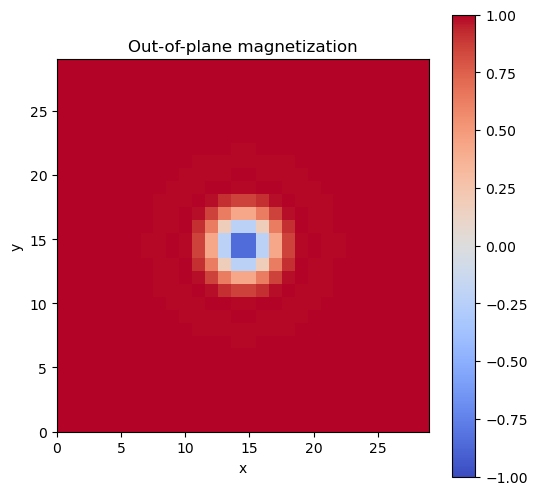

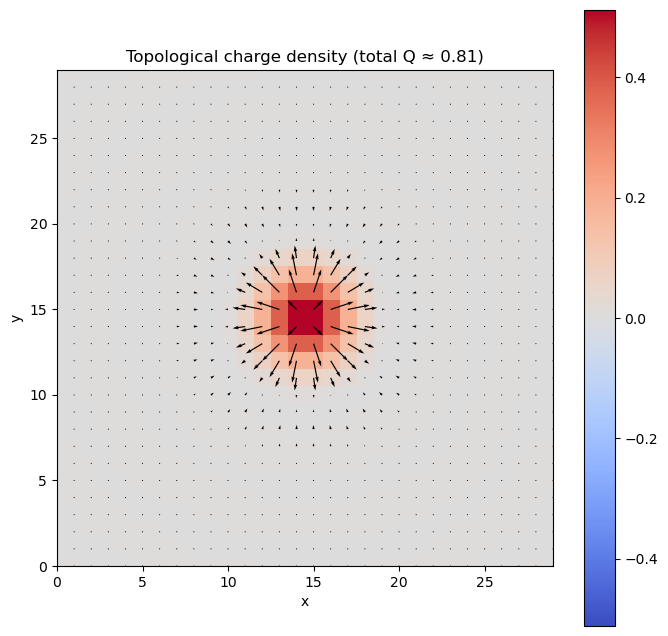

In [57]:
def show(n):
    x0 = 0; x1 = n.shape[1]-1

    #spin z
    plt.figure(figsize=(6,6))
    plt.imshow(n[2,:,:], vmin=-1,vmax=1,cmap='coolwarm')
    plt.xlim(x0,x1); plt.ylim(x0,x1)
    plt.xlabel("x"); plt.ylabel("y")
    plt.title("Out-of-plane magnetization")
    plt.colorbar()


    #in-plane
    plt.figure(figsize=(8, 8))
    plt.quiver(n[0,:,:], n[1,:,:], scale=20)
    plt.xlim(x0,x1); plt.ylim(x0,x1)
    plt.xlabel("x"); plt.ylabel("y")

    Q, density = topological_charge(n)
    max_d = np.max(np.abs(density))
    plt.imshow(density, cmap='coolwarm',vmin=-max_d, vmax=max_d)
    plt.title(f'Topological charge density (total Q ≈ {Q:.2f})')
    plt.colorbar()

show(n)

## Understanding the lattice parameters

In [58]:
def B_uniform(nx,ny,B_val, rim=False,rim_val=5.0):
    B = B_val*np.ones((nx,ny))
    if rim:
        large_B = rim_val
        B[0,:] = large_B; B[-1,:] = large_B
        B[:,0] = large_B; B[:,-1] = large_B
    return B*np.ones((nx,ny))
#end

def local_B_field(nx,ny,B_val,r,sigma=1.0):
    X,Y = np.meshgrid(1.0*np.arange(nx),1.0*np.arange(ny))
    #shift the centre
    X -= (nx-1)//2+0.5
    Y -= (ny-1)//2+0.5
    R = np.sqrt(X**2+Y**2)
    return B_val*( (R<=r) + (R>=r)*np.exp(-(R-r)**2/sigma**2) )

In [30]:
def describe_mean_field(J1,J2,J3):
    I1 = -2*(J1+J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    print("I1 = ", I1,"\nI2 = ", I2)
    print("spatial anisotropy ratio : ", I3/I2)
    x0 = np.sqrt(I2/I1)
    print("sqrt(I2/I1) length scale = ", x0)
    print("H_MF = ",I2/I1**2, " H_Micro")
    return x0

nx = 30; ny = 30
J1 = 1.0; J2 = -0.4; J3 = 1/16*(-J1+4*J2)
describe_mean_field(J1,J2,J3)

I1 =  0.10000000000000009 
I2 =  0.4
spatial anisotropy ratio :  0.0
sqrt(I2/I1) length scale =  1.9999999999999991
H_MF =  39.99999999999993  H_Micro


np.float64(1.9999999999999991)

In [1]:
def H_vect(n,J1,J2,J3,K,B,boundary):
    E = 0
    nx = n.shape[1]; ny = n.shape[2]
    for i in range(nx):
        for j in range(ny):
            n_a = n[:,i,j]
            #account for the anisotropy
            E -= K*n_a[2]**2
            #add external field
            E -= B[i,j]*n_a[2]
            for (k,l) in [(i+1,j),(i,j+1)]:
                if boundary == "periodic":
                    k = k%nx; l = j%ny; # periodic BCs
                else: #free BCs
                    if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                        continue
                    #endif
                #endif
                n_b = n[:,k,l]
                E -= J1*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                if boundary == "periodic":
                    k = k%nx; l = j%ny; # periodic BCs
                else: #free BCs
                    if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                        continue
                    #endif
                #endif
                n_b = n[:,k,l]
                E -= J2*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
            for (k,l) in [(i+2,j),(i,j+2)]:
                if boundary == "periodic":
                    k = k%nx; l = j%ny; # periodic BCs
                else: #free BCs
                    if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                        continue
                    #endif
                #endif
                n_b = n[:,k,l]
                E -= J3*( n_a[0]*n_b[0]+n_a[1]*n_b[1]+n_a[2]*n_b[2] )
        #end
    #end

    #subtract the energy of the FM state
    if boundary == "periodic":
        E += np.sum(B)+nx*ny*(K+2*J1+2*J2+2*J3)
    elif boundary == "free":
        E += np.sum(B)+nx*ny*K + J1*(2*nx*ny-1*(nx+ny))+J2*(2*nx*ny-2*(nx+ny)+2)+J3*(2*nx*ny-2*(nx+ny))
    return E
#end

n = ferromagnetic(50,37)
boundary = "free"
H_vect(n,1.0, -0.232, -0.171, 0.323, B_uniform(50,37,1.23),boundary="free")

NameError: name 'ferromagnetic' is not defined

### Testing H

In [74]:
def random_configuration(nx,ny):
    n = np.random.normal(size=(3,nx,ny))
    for i in range(nx):
        for j in range(ny):
            n[:,i,j] *= 1/np.sqrt(np.sum(n[:,i,j]**2))
    return n

def rotate_around_z(n,phi):
    n[0,:,:], n[1,:,:] = np.cos(phi)*n[0,:,:]+np.sin(phi)*n[1,:,:], -np.sin(phi)*n[0,:,:]+np.cos(phi)*n[1,:,:]
    return n

In [75]:
#H_vect(n,J1,J2,J3,K,B,boundary)
J1 = 1.11; J2 = -0.53; J3 = 1/16*(-J1+4*J2)+0.07; K = 0.002; B = B_uniform(nx,ny,0.37)
n = random_configuration(nx,ny)
H_vect

<function __main__.H_vect(n, J1, J2, J3, K, B, boundary)>

In [98]:
n = random_configuration(1,1)
n

array([[[-0.00447439]],

       [[-0.99391907]],

       [[-0.11002211]]])

In [99]:
rotate_around_z(n,2.3*np.pi)

array([[[-0.8067274 ]],

       [[-0.58059111]],

       [[-0.11002211]]])

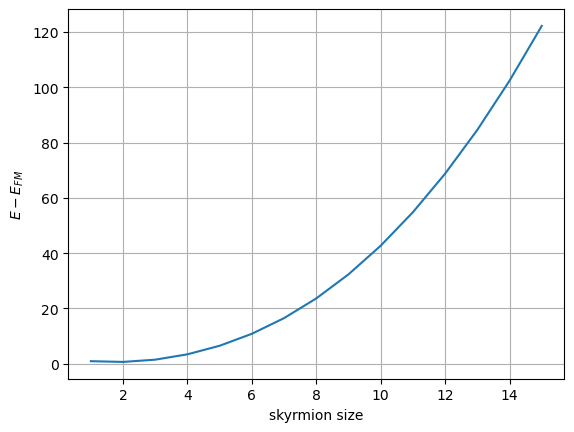

In [34]:
b_vals = np.linspace(1.0,15,15)
H_vals = []
for b in b_vals:
    n = skyrmion_ansatz(b, nx, ny)
    E = H_vect(n,J1,J2,J3,K,B_uniform(nx,ny,0.20),boundary="free")
    H_vals.append(E)
#end

plt.plot(b_vals,H_vals)
plt.xlabel("skyrmion size"); plt.ylabel("$E-E_{FM}$")
plt.grid()

A BIG problem might be that in a uniform setting, if a skyrmion detects algebraically, the contribution from boundary conditions might carry a lot of weight !

## Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.


Maybe a ($n^2=1$ constrained) variant of Newton's method could be used? The Hessian is easy enough to compute, since $H$ is quadratic in $n$.

I1 =  0.5 
I2 =  0.5
spatial anisotropy ratio :  0.0
sqrt(I2/I1) length scale =  1.0
H_MF =  2.0 * H_Micro =  0.6


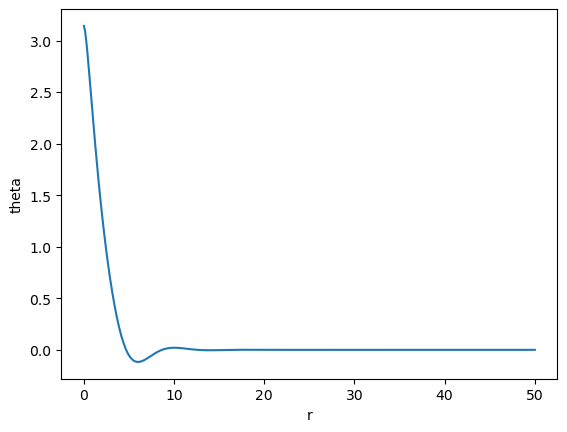

step 0
step 100
step 200
step 300
step 400
step 500
step 600
step 700
step 800
step 900


/tmp/ipykernel_12232/303033147.py:71: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,8))


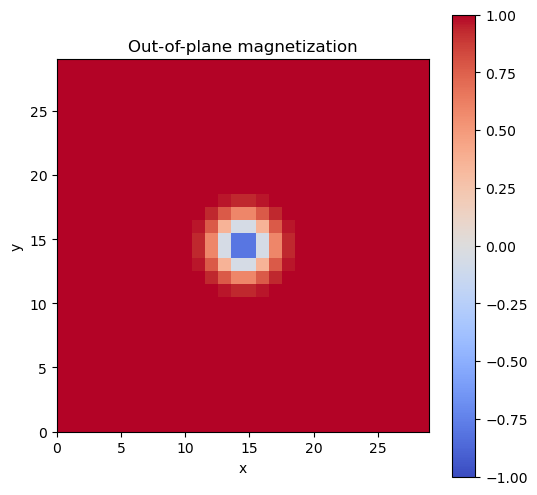

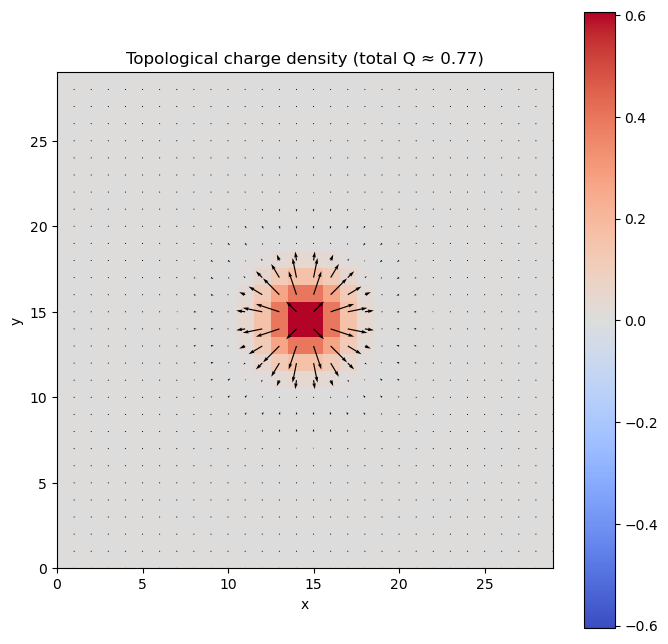

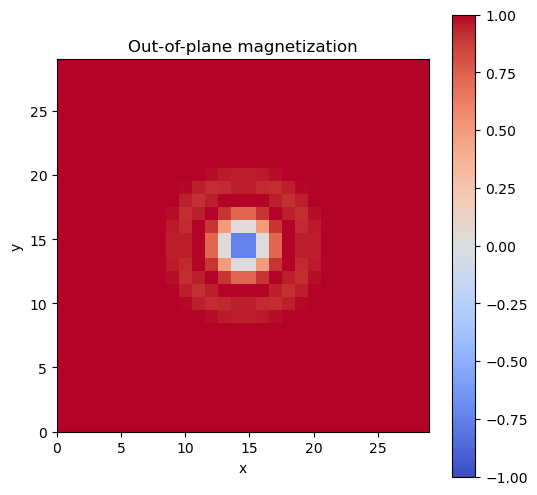

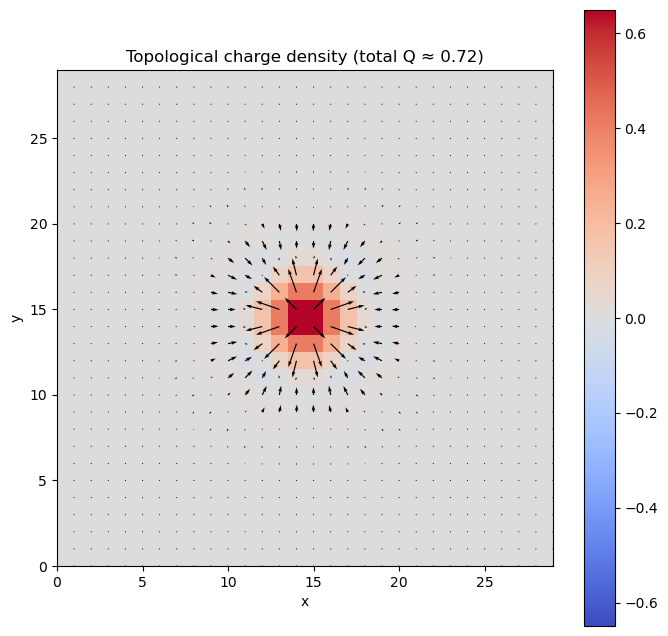

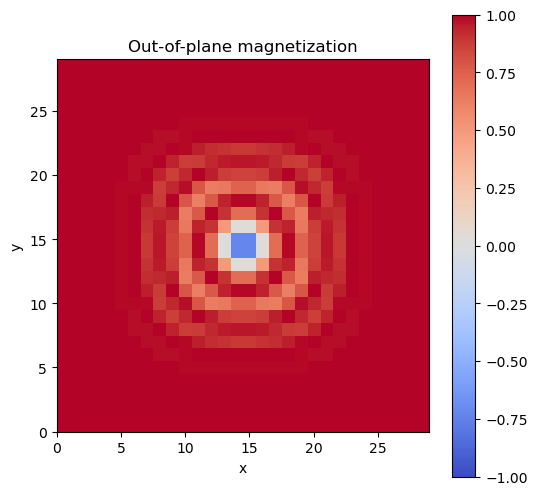

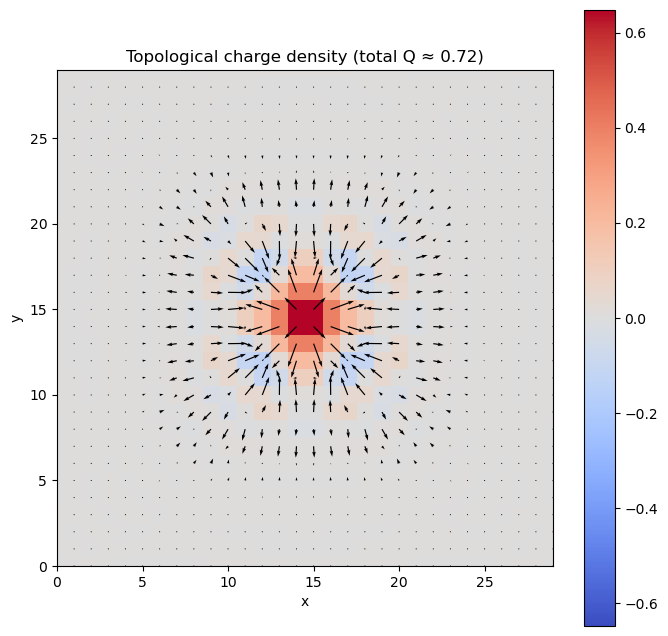

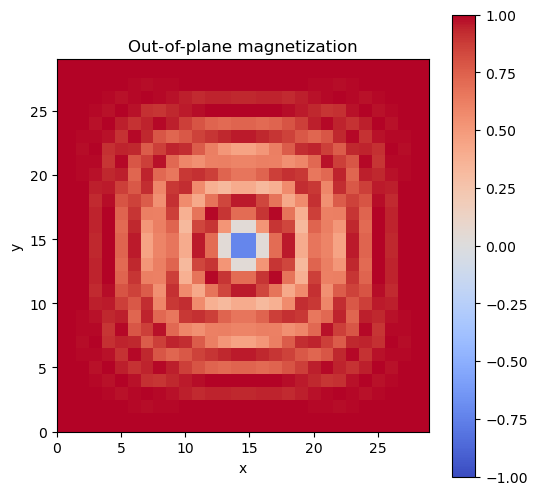

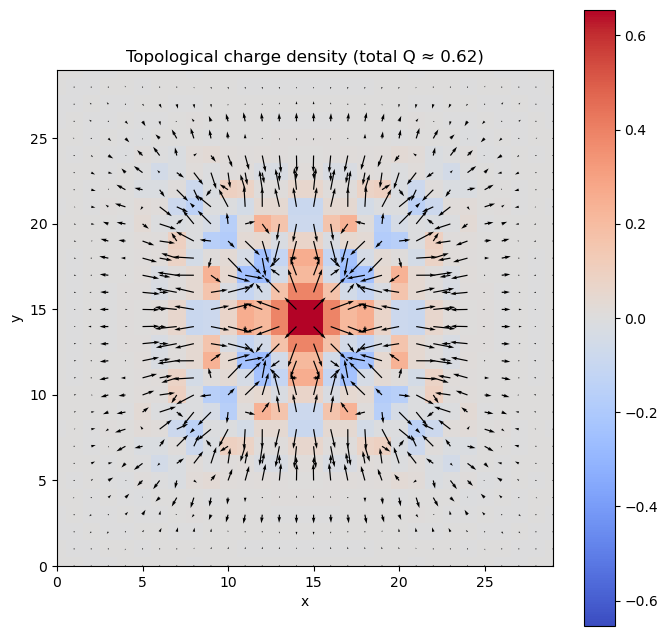

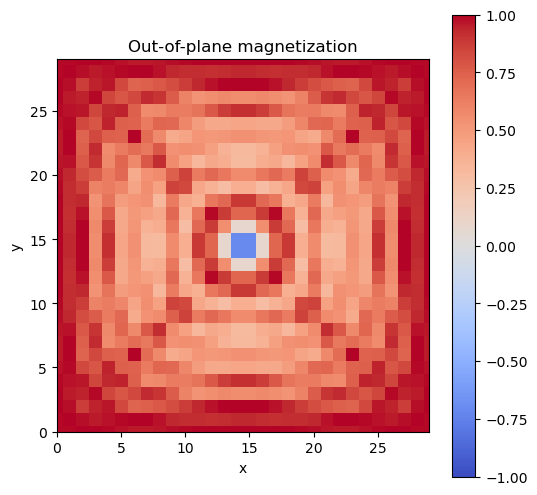

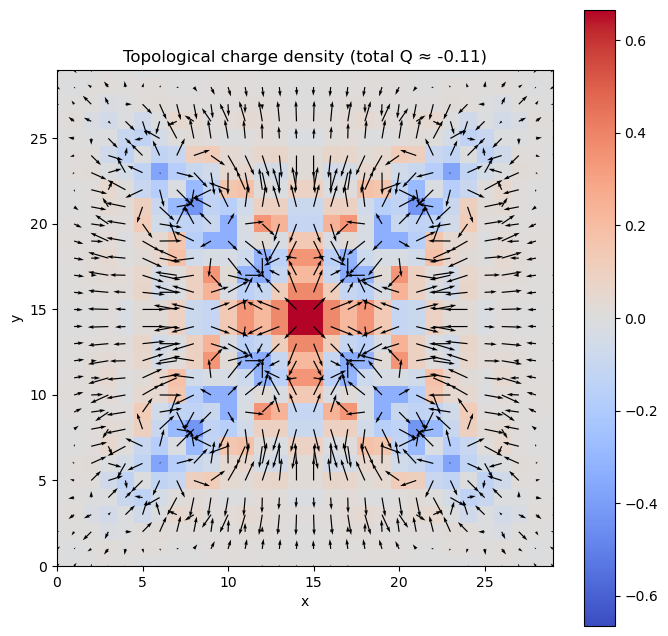

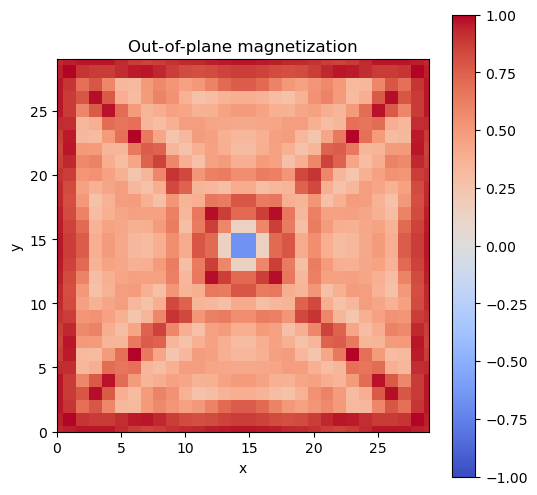

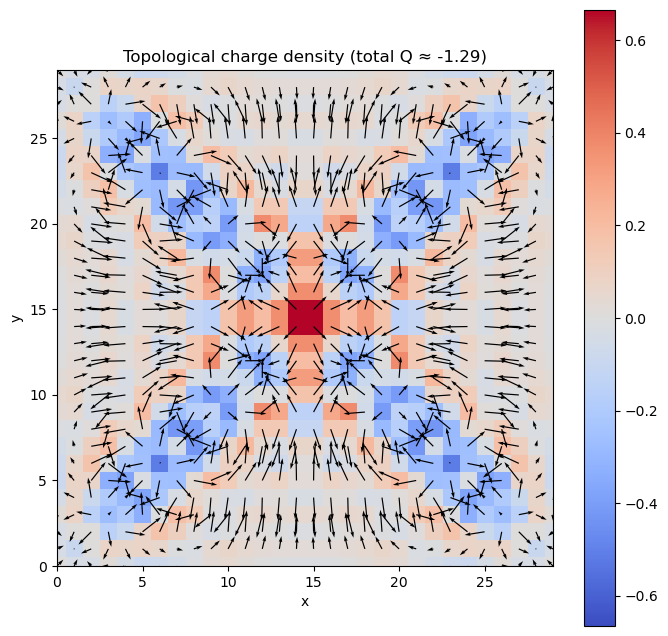

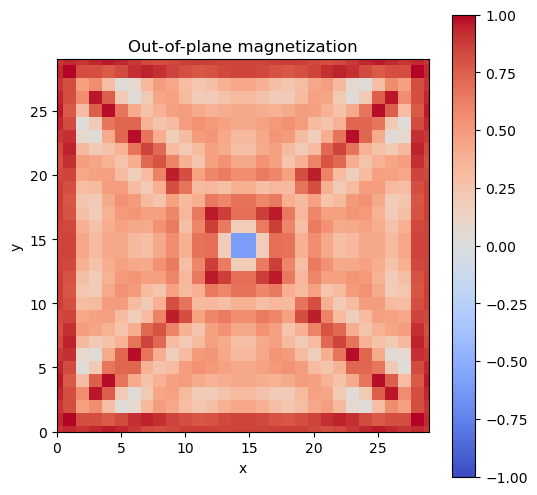

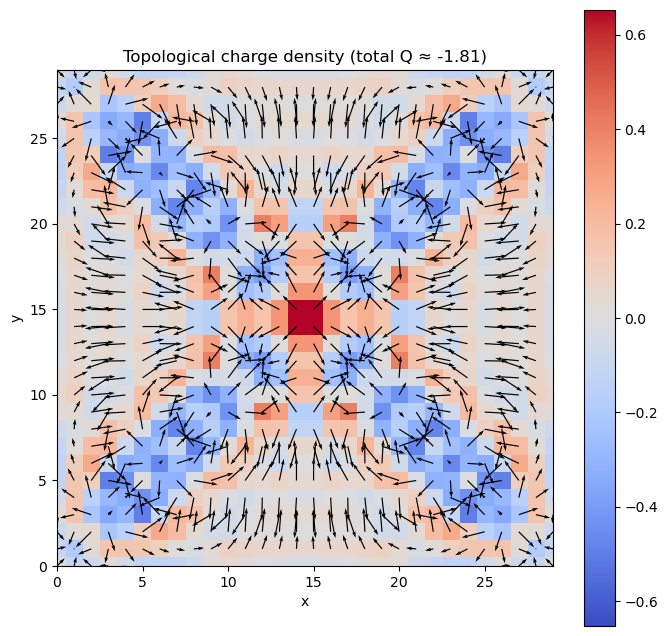

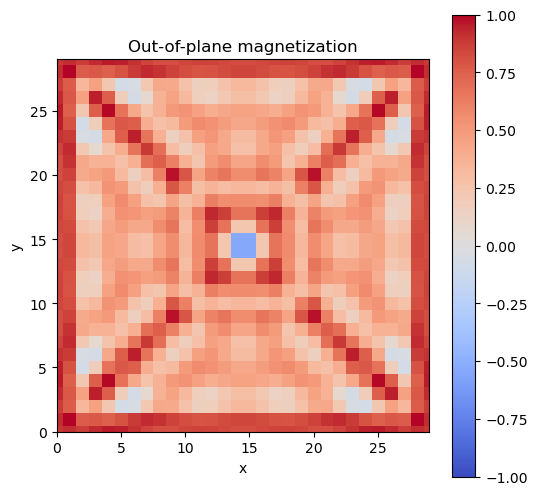

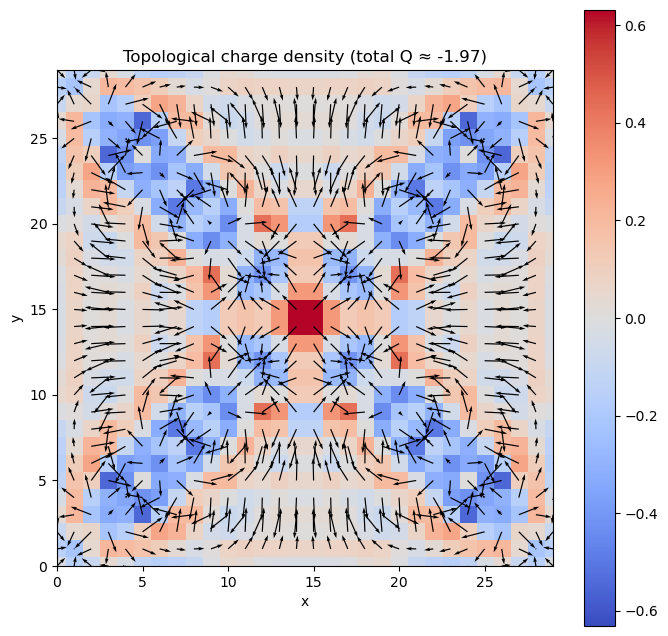

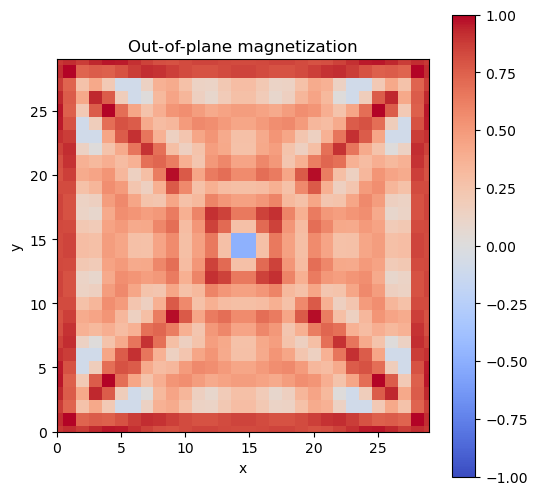

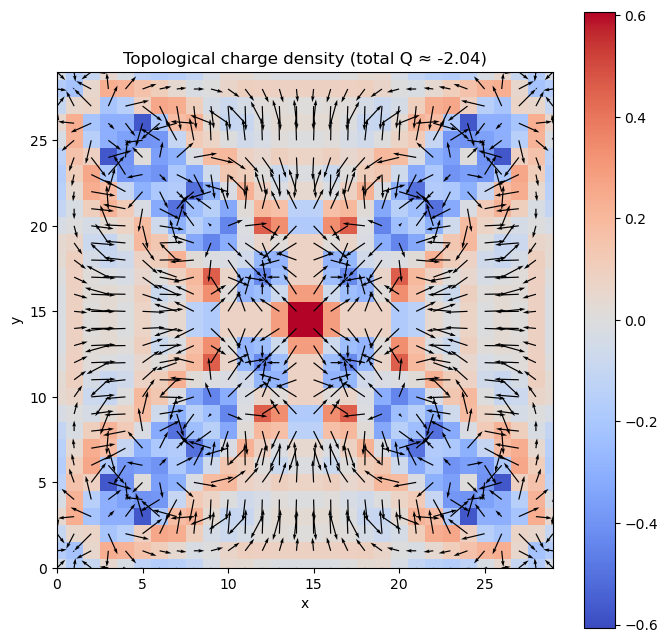

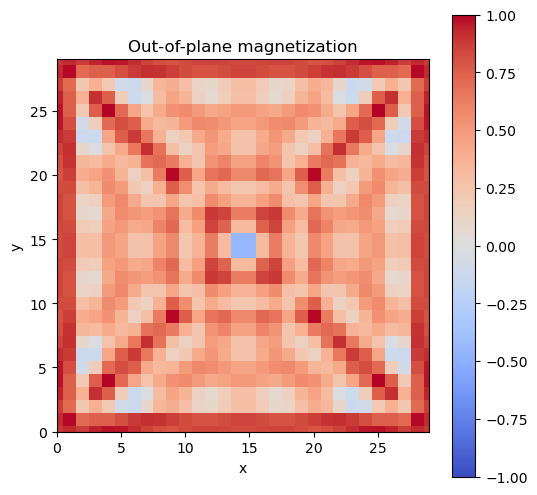

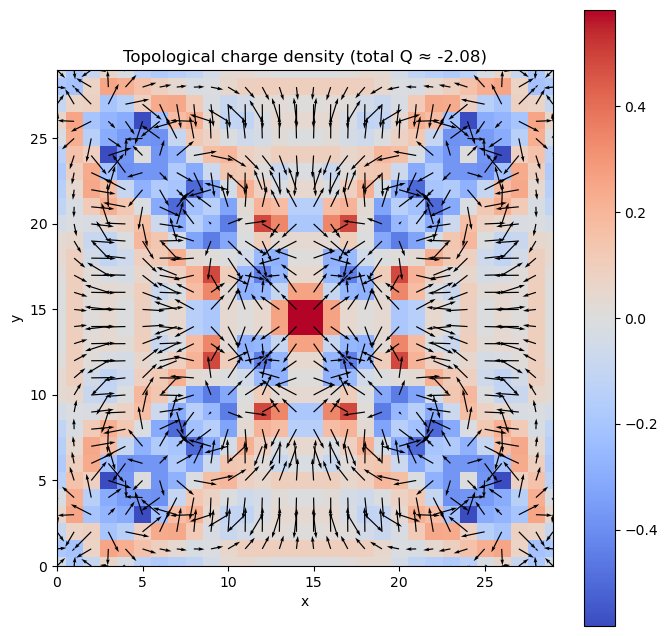

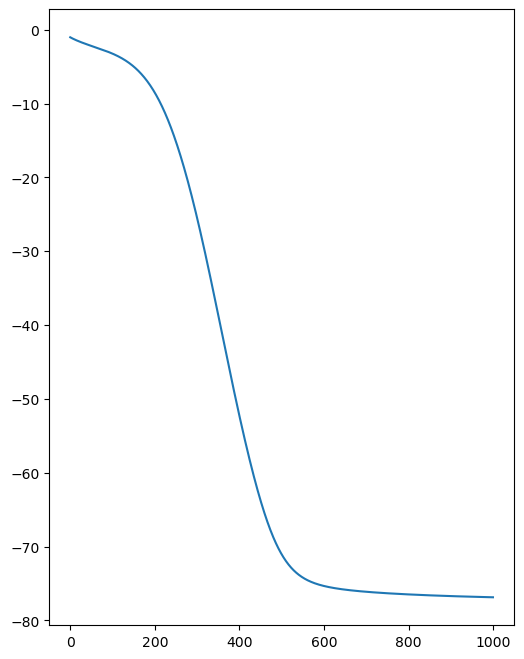

In [41]:
def relax(n_init, nx, ny, J1, J2, J3, K, B, dt, N_steps, boundary):
    """
    Gradient descent on H
    """
    def F(n,nx,ny,J1,J2,J3,K,B,boundary):
        g = np.zeros_like(n) # MINUS the gradient of H
        for i in range(nx):
            for j in range(ny):
                #external field
                g[2,i,j] += B[i,j]
                #anisotropy
                g[:,i,j] += 2*K*n[:,i,j]

                for (k,l) in [(i+1,j),(i,j+1)]:
                    if boundary == "periodic":
                        k = k%nx; l = j%ny; # periodic BCs
                    else: #free BCs
                        if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                            continue
                        #endif
                    #endif
                    g[:,i,j] += J1* n[:,k,l]
                    g[:,k,l] += J1* n[:,i,j]

                for (k,l) in [(i+1,j+1),(i+1,j-1)]:
                    if boundary == "periodic":
                        k = k%nx; l = j%ny; # periodic BCs
                    else: #free BCs
                        if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                            continue
                        #endif
                    #endif
                    g[:,i,j] += J2* n[:,k,l]
                    g[:,k,l] += J2* n[:,i,j]

                for (k,l) in [(i+2,j),(i,j+2)]:
                    if boundary == "periodic":
                        k = k%nx; l = j%ny; # periodic BCs
                    else: #free BCs
                        if (k>=nx) or (l>=ny) or (k<0) or (l<0):
                            continue
                        #endif
                    #endif
                    g[:,i,j] += J3* n[:,k,l]
                    g[:,k,l] += J3* n[:,i,j]
            #end
        #end

        for i in range(nx):
            for j in range(ny):
                gn = n[0,i,j]*g[0,i,j] + n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j]
                g[:,i,j] = g[:,i,j] - gn*n[:,i,j]
        return g
    #endfunction


    n = np.zeros_like(n_init)
    H_vals = np.zeros(N_steps)
    n = n_init
    for i in range(N_steps):
        k1 = F(n, nx, ny, J1, J2, J3, K, B,boundary)
        #adaptive time step
        #maxf = np.max(np.abs(k1))
        #dt = 5E-2/ maxf
        #print("dt = ", dt)
        n += k1*dt
        H_vals[i] = H_vect(n,J1,J2,J3,K,B,boundary)
        if i%100 ==0:
            print("step",i)
            show(n)
    plt.figure(figsize=(6,8))
    plt.plot(H_vals)
    return n
#end

def skyrmion_minimum(nx, ny, J1, J2, J3, K, B, dt=0.05, N_steps=50, boundary="free"):
    """
    #see what kind of skyrmion has optimal size
    b_vals = np.linspace(1.0,5,12)
    H_vals = []
    for b in b_vals:
        n = skyrmion_ansatz(b, nx, ny)
        E = H_vect(n,J1,J2,J3,K,B,boundary)
        H_vals.append(E)
    #end
    b = b_vals[np.argmin(H_vals)]
    if b<2.0:
        b = 10.0
    print("staring from a hedgehog of size ", b)
    """
    n_init = mean_field_skyrmion(nx,ny,J1,J2,J3,B[nx//2,ny//2])
    return relax(n_init,nx,ny,J1,J2,J3,K,B,dt,N_steps,boundary)


nx = 30; ny = 30
B = B_uniform(nx,ny,0.30)
J1 = 1.0; J2 = -0.5; J3 = 1/16*(-J1+4*J2); K = 0.0
n_Sk = skyrmion_minimum(nx,ny,J1,J2,J3,K,B,dt=0.05,N_steps=1000)

My skyrmions are destabilized by BOUNDARY EFFECTS

In [43]:
def check_norm(n):
    norm = n[0,:,:]**2 + n[1,:,:]**2 + n[2,:,:]**2
    print("norm varies from", np.min(norm), "to", np.max(norm))
check_norm(n_Sk)

norm varies from 1.0000000012726458 to 1.0000041208029158


A square lattice of skyrmions is destabilized by a magnon excitation.

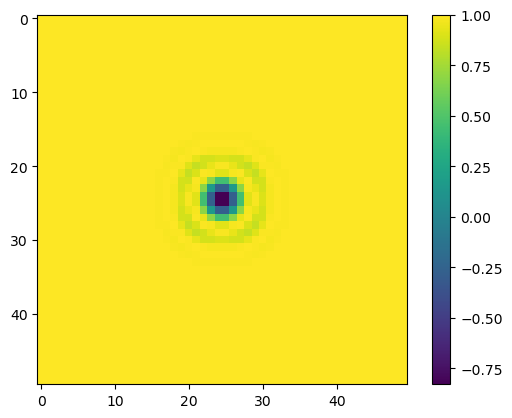

In [ ]:
plt.imshow(n_Sk[2,:,:])
plt.colorbar()

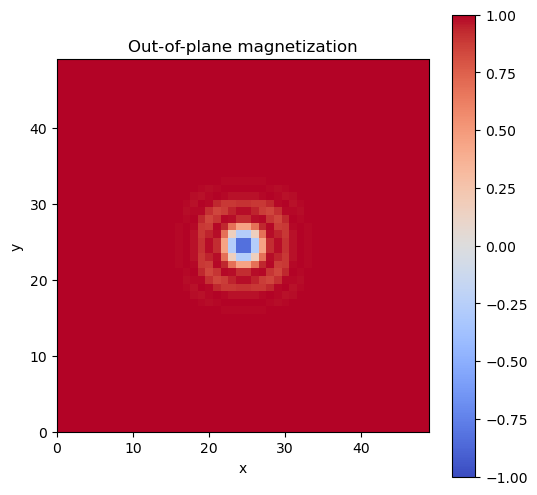

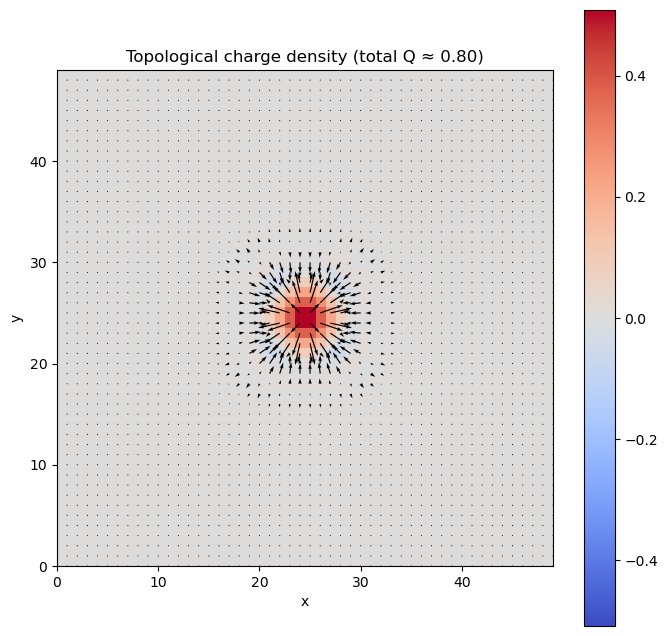

In [ ]:
show(n_Sk)

## Sterographic projection and the Hamiltonian

$$
n_x = \frac{w + \bar{w}}{1+\bar{w}w} \qquad n_y = -i \frac{w - \bar{w}}{1+\bar{w}w} \qquad n_z = \frac{1-\bar{w}w}{1+\bar{w}w} 
$$

The inverse mapping is

$$
|w|^2 = \frac{1-n_z}{1+n_z} \qquad w = \frac{n_x + i n_y}{1+n_z}
$$

In [48]:
def w_project(n):
    w = np.zeros((n.shape[1], n.shape[2]),dtype=complex)
    w = (n[0,:,:]+ 1j*n[1,:,:]) / (1+n[2,:,:])
    return w
#end

def n_vector(w):
    n = np.zeros((3, w.shape[0], w.shape[1]))
    n[0,:,:] = np.real( (w + np.conj(w)) / (1 + np.conj(w)*w) )
    n[1,:,:] = np.real(-1j * (w - np.conj(w)) / (1 + np.conj(w)*w))
    n[2,:,:] = np.real((1-w*np.conj(w)) / (1 + np.conj(w)*w))
    return n
#end

In [49]:
def w(w0, lbd):
    return np.real(w0) + 1j*lbd*np.imag(w0)

def n_lbd(w0, lbd):
    return n_vector(w(w0,lbd))

In [50]:
w0 = w_project(mean_field_skyrmion(nx,ny,J1,J2,J3,B))
#w0 = w_project(skyrmion_ansatz(3.0,nx,ny))
lbd_vals = np.linspace(-2.0, 2.0, 101)
H_vals = []
Q_vals = []
for lbd in lbd_vals:
    n = n_vector(w(w0,lbd))
    Q, density = topological_charge(n)
    #check_norm(n)
    H_vals.append(H_vect(n,J1,J2,J3,K,B,boundary="free"))
    Q_vals.append(Q)
plt.plot(lbd_vals,H_vals)


I1 =  0.5 
I2 =  0.5
spatial anisotropy ratio :  0.0
sqrt(I2/I1) length scale =  1.0
H_MF =  2.0 * H_Micro =  [[0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6]
 [0.6 0.6 0.6 0

ValueError: operands could not be broadcast together with shapes (30,30) (400,) 

In [ ]:
plt.plot(lbd_vals,Q_vals)
plt.xlabel("$\lambda$"); plt.ylabel("$Q$")
plt.xlim(-1,1)
plt.grid()

NameError: name 'lbd_vals' is not defined

I need to
1. Test my H function
2. Make sure gradient-descent works well
3. Visualize and understand the configurations.
4. Scrutinize the choice of parameters (consider adding anisotropy, too!)

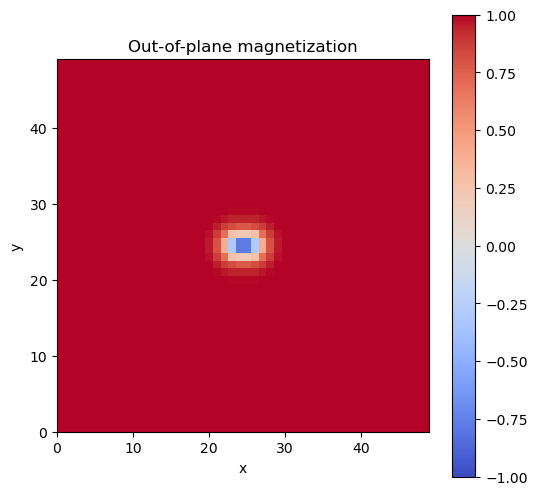

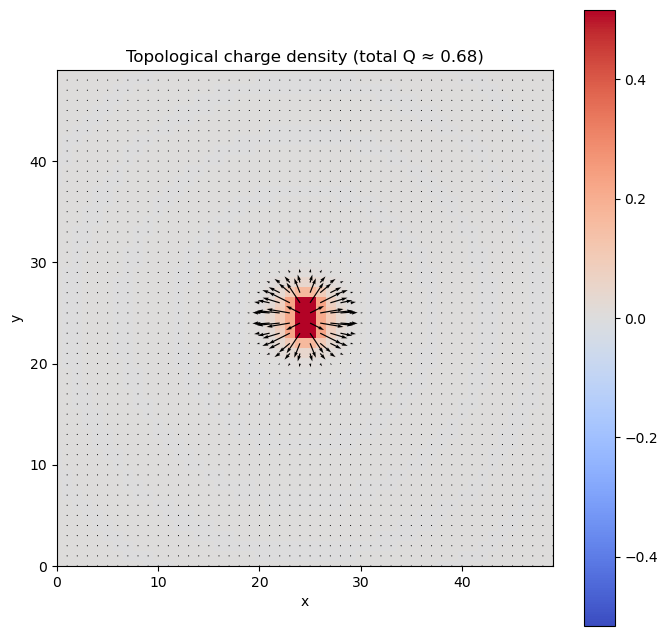

In [ ]:
lbd = 0.5
show(n_vector(w(w0,lbd)))

# Imaginary time dynamics

$$
\vec{n} \cdot \vec{n}' = \frac{2w \bar{w}'+2\bar{w}w'+(1-\bar{w}w)(1-\bar{w}'w')}{(1+\bar{w}w)(1+\bar{w}'w')}
$$

In [46]:
def H(w,z,nx,ny,J1,J2,J3,K,B,boundary):
    E = 0.0
    #sum over all bonds
    for i in range(nx):
        for j in range(ny):
            w1 = w[i,j]; z1 = z[i,j];
            for k,l,J in [(i+1,j,J1), (i,j+1,J1), (i+1,j+1,J2), (i+1,j-1,J2), (i+2,j,J3), (i,j+2,J3)]:
                if boundary == "free":
                    if k<0 or l<0 or k>=nx or l >= ny:
                        continue
                elif boundary == "periodic":
                    k = k%nx; l = l%ny
                #endif
                
                w2 = w[k,l]; z2 = z[k,l]
                
                E += -J * ( 2*(w1*z2 + z1*w2) + (1-z1*w1)*(1-z2*w2) ) / ( (1+w1*z1)*(1+w2*z2) )
            #end bond sum
            n_z = (1-w1*z1)/(1+w1*z1);
            E += -B[i,j]*n_z - K*n_z**2
        #next i
    #next j

    # subtract the ferromagnetic state energy
    if boundary == "free":
        E += J1*(2*nx*ny - (nx+ny)) + J2*(2*nx*ny-2*(nx+ny)+1) + J3*(2*nx*ny-2*(nx+ny)) + np.sum(B) + K*nx*ny
    elif boundary == "periodic":
        E += nx*ny*(2*J1+2*J2+2*J3+K) + np.sum(B)
    return E
#end
K = 0.0
H(w0,np.conj(w0),nx,ny,J1,J2,J3,K,B,boundary)

NameError: name 'w0' is not defined

In [47]:
def dHdl(w0,w,z,nx,ny,J1,J2,J3,K,B,boundary):
    dH = 0.0
    #sum over all bonds
    dw = (w0-np.conj(w0))/2
    for i in range(nx):
        for j in range(ny):
            w1 = w[i,j]; z1 = z[i,j]; dw1 = dw[i,j]
            for k,l,J in [(i+1,j,J1), (i,j+1,J1), (i+1,j+1,J2), (i+1,j-1,J2), (i+2,j,J3), (i,j+2,J3)]:
                if boundary == "free":
                    if k<0 or l<0 or k>=nx or l >= ny:
                        continue
                elif boundary == "periodic":
                    k = k%nx; l = l%ny
                #endif
                
                w2 = w[k,l]; z2 = z[k,l]; dw2 = dw[k,l]
                
                dH += -2*J / ((1+w1*z1)*(1+w2*z2)) * ( dw1*(z2-z1*z1*w2-z1*(1-w2*z2))/(1+w1*z1) + dw2*(z1-z2*z2*w1-z2*(1-w1*z1))/(1+w2*z2) )
            #end bond sum
            n_z = (1-w1*z1)/(1+w1*z1);
            dn_z = -2*z1/(1+w1*z1)
            dH += -B[i,j]*dn_z - K*2*n_z*dn_z
        #next i
    #next j   
    return dH
#end

def M(w0,w,z):
    return np.sum( np.imag(w0)**2 / (1+w*z )**2 )
#end

def v(w0,lambda_,lambda_bar, nx, ny, J1, J2, J3, K, B, boundary):
    #compute the field
    w = np.real(w0) + 1j*np.imag(w0)*lambda_
    z = np.real(w0) - 1j*np.imag(w0)*lambda_bar
    M_val = M(w0,w,z)
    dHdlambda = dHdl(w0,w,z,nx,ny,J1,J2,J3,K,B,boundary)
    dHdlambda_bar = -dHdl(w0,z,w,nx,ny,J1,J2,J3,K,B,boundary) #notice the minus sign and the exchange w <> z. It is justified by a symmetry argument
    return -dHdlambda_bar/M_val, dHdlambda/M_val
#end

v(w0,4.0,-1.0,nx,ny,J1,J2,J3,K,B,boundary)

NameError: name 'w0' is not defined

If $\lambda$ and $\bar{\lambda}$ start off real (not necessarily equal), do they stay that way?

In [ ]:
l0 = 1.3
number_of_arrows = 15
x = np.linspace(-l0,l0,number_of_arrows)
y = np.linspace(-l0,l0,number_of_arrows)
X,Y = np.meshgrid(x,y)

V1 = np.zeros((number_of_arrows,number_of_arrows),complex); V2 = np.zeros_like(V1)
for i in range(number_of_arrows):
    for j in range(number_of_arrows):
        V1[i,j], V2[i,j] = v(w0,X[i,j],Y[i,j],nx,ny,J1,J2,J3,K,B,boundary)

print(np.max(np.abs(np.imag(V1))))
print(np.max(np.abs(np.imag(V2))))

1.1743539711012491e-14
1.1755564296385402e-14


As of now, it takes 0.11 s to perform a SINGLE evaluation...

Text(0, 0.5, '$\\lambda$ bar')

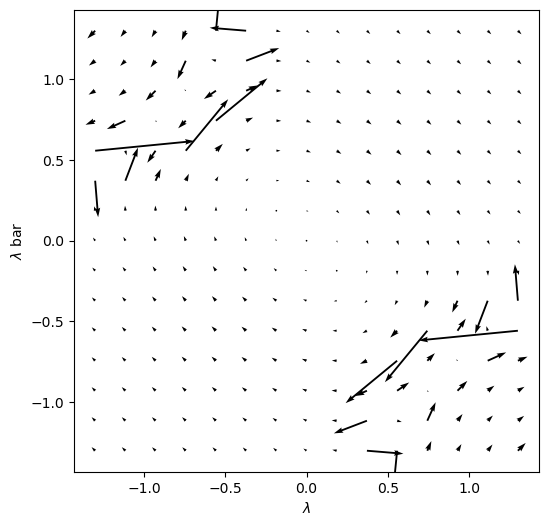

In [ ]:
plt.figure(figsize=(6,6))
plt.quiver(X,Y,V1,V2,scale=20)
plt.xlabel("$\lambda$")
plt.ylabel("$\lambda$ bar")

In [ ]:
lbd = np.linspace(-1.2, 1.2, 50)
H_vals = np.zeros((50,50),complex)


In [ ]:
def calc_H(w0,lambda_,lambda_bar,nx,ny,J1,J2,J3,K,B,boundary):
    w = np.real(w0) + 1j*np.imag(w0)*lambda_
    z = np.real(w0) - 1j*np.imag(w0)*lambda_bar
    return H(w,z,nx,ny,J1,J2,J3,K,B,boundary)
#end